## 1. Setup and Configuration

In [26]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import chi2, skew, kurtosis, jarque_bera
from scipy.stats import f as f_dist

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.vector_ar.vecm import VECM, select_order, select_coint_rank, coint_johansen
from statsmodels.graphics.tsaplots import plot_acf

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

SCRIPT_DIR = os.getcwd()
DATA_DIR = os.path.join(SCRIPT_DIR, 'data', 'processed')

print(f'Data Directory: {DATA_DIR}')

Data Directory: d:\Nam4-HK1\KLTN\Vietnam_economic_lakehouse\model_test\data\processed


## 2. Load Data

In [27]:
cleaned_data = pd.read_csv(os.path.join(DATA_DIR, 'step1_cleaned_data.csv'))
cleaned_data['date'] = pd.to_datetime(cleaned_data['date'])
cleaned_data = cleaned_data.sort_values('date').reset_index(drop=True)

print(f'Loaded cleaned data: {cleaned_data.shape[0]} months × {cleaned_data.shape[1]} columns')
print(f"Date range: {cleaned_data['date'].min().date()} to {cleaned_data['date'].max().date()}")
print(f'Missing values: {cleaned_data.isnull().sum().sum()}')

key_vars = [
    'cpi_mom', 'cpi_base_year', 'core_inflation_rate', 'm2',
    'gasoline_world_last', 'silver_last', 'S&P500_last',
    'USDVND_last', 'UPCOM_last', 'ppi_qoq'
]

available_vars = [v for v in key_vars if v in cleaned_data.columns]
print(f'Available key variables: {available_vars}')


Loaded cleaned data: 95 months × 31 columns
Date range: 2018-06-01 to 2026-04-01
Missing values: 0
Available key variables: ['cpi_mom', 'cpi_base_year', 'core_inflation_rate', 'm2', 'gasoline_world_last', 'silver_last', 'S&P500_last', 'USDVND_last', 'UPCOM_last', 'ppi_qoq']


## 3. Select Variables and Transform Data

In [28]:
## 2.5. Check M2 for Negative Values
m2_check = cleaned_data[['date', 'm2']].copy() if 'm2' in cleaned_data.columns else None

if m2_check is not None:
    print("="*80)
    print("CHECK: M2 VARIABLE FOR NEGATIVE VALUES")
    print("="*80)
    
    print(f"\nM2 basic statistics in cleaned_data:")
    print(f"  Min value: {cleaned_data['m2'].min():.6f}")
    print(f"  Max value: {cleaned_data['m2'].max():.6f}")
    print(f"  Mean: {cleaned_data['m2'].mean():.6f}")
    print(f"  Std: {cleaned_data['m2'].std():.6f}")
    print(f"  Count of negative values: {(cleaned_data['m2'] < 0).sum()}")
    print(f"  Count of zero values: {(cleaned_data['m2'] == 0).sum()}")
    print(f"  Count of NaN values: {cleaned_data['m2'].isna().sum()}")
    
    # Show rows with negative or zero m2
    negative_m2 = cleaned_data[cleaned_data['m2'] <= 0][['date', 'm2']]
    if len(negative_m2) > 0:
        print(f"\n⚠️ FOUND {len(negative_m2)} rows with m2 <= 0:")
        print(negative_m2.to_string(index=False))
    else:
        print("\n✓ All m2 values are positive")
    
    # Check m2 in vecm_data (after dropna)
    if 'm2' in vecm_data.columns:
        print(f"\nM2 statistics in vecm_data (after dropna):")
        print(f"  Min value: {vecm_data['m2'].min():.6f}")
        print(f"  Max value: {vecm_data['m2'].max():.6f}")
        print(f"  Count of negative values: {(vecm_data['m2'] < 0).sum()}")
else:
    print("⚠️ m2 not found in cleaned_data")


CHECK: M2 VARIABLE FOR NEGATIVE VALUES

M2 basic statistics in cleaned_data:
  Min value: 0.000000
  Max value: 19980717.000000
  Mean: 12437917.421053
  Std: 4577571.915404
  Count of negative values: 0
  Count of zero values: 7
  Count of NaN values: 0

⚠️ FOUND 7 rows with m2 <= 0:
      date  m2
2025-10-01 0.0
2025-11-01 0.0
2025-12-01 0.0
2026-01-01 0.0
2026-02-01 0.0
2026-03-01 0.0
2026-04-01 0.0

M2 statistics in vecm_data (after dropna):
  Min value: 8842552.000000
  Max value: 19980717.000000
  Count of negative values: 0


In [29]:
## Check impact of zero m2 on log transformation
if m2_check is not None:
    print("\n" + "="*80)
    print("CHECK: IMPACT OF ZERO M2 ON LOG-TRANSFORMATION")
    print("="*80)
    
    # Try log transform on m2
    m2_log_test = np.log(cleaned_data['m2'])
    
    print(f"\nAfter np.log(m2):")
    print(f"  Count of -inf values: {np.isinf(m2_log_test).sum()}")
    print(f"  Count of NaN values: {np.isnan(m2_log_test).sum()}")
    print(f"  Min value: {m2_log_test[~np.isinf(m2_log_test)].min():.6f}")
    
    if np.isinf(m2_log_test).sum() > 0 or np.isnan(m2_log_test).sum() > 0:
        print(f"\n❌ PROBLEM FOUND: log(0) = -∞ creates inf/NaN values!")
        print(f"   This will break the VECM model.")
        
        # Show where inf/nan would occur
        indices = np.where(np.isinf(m2_log_test) | np.isnan(m2_log_test))[0]
        if len(indices) <= 10:
            for idx in indices:
                print(f"   Row {idx}: m2={cleaned_data['m2'].iloc[idx]} → log(m2)={m2_log_test.iloc[idx]}")
        
        print(f"\n💡 SOLUTIONS:")
        print(f"   1. Replace m2=0 with minimum positive value before log-transform")
        print(f"   2. Drop rows where m2=0")
        print(f"   3. Don't log-transform m2 (use original scale)")



CHECK: IMPACT OF ZERO M2 ON LOG-TRANSFORMATION

After np.log(m2):
  Count of -inf values: 7
  Count of NaN values: 0
  Min value: 15.995086

❌ PROBLEM FOUND: log(0) = -∞ creates inf/NaN values!
   This will break the VECM model.
   Row 88: m2=0.0 → log(m2)=-inf
   Row 89: m2=0.0 → log(m2)=-inf
   Row 90: m2=0.0 → log(m2)=-inf
   Row 91: m2=0.0 → log(m2)=-inf
   Row 92: m2=0.0 → log(m2)=-inf
   Row 93: m2=0.0 → log(m2)=-inf
   Row 94: m2=0.0 → log(m2)=-inf

💡 SOLUTIONS:
   1. Replace m2=0 with minimum positive value before log-transform
   2. Drop rows where m2=0
   3. Don't log-transform m2 (use original scale)


In [30]:
## FIX: Handle m2=0 values
print("\n" + "="*80)
print("FIX: HANDLE M2=0 VALUES")
print("="*80)

# Option 1: Drop rows with m2=0 (RECOMMENDED)
print("\n✓ Solution: Drop rows with m2=0")
print(f"  Before: {len(cleaned_data)} rows")

cleaned_data = cleaned_data[cleaned_data['m2'] > 0].reset_index(drop=True)
print(f"  After: {len(cleaned_data)} rows")
print(f"  Dropped: {len(pd.read_csv(os.path.join(DATA_DIR, 'step1_cleaned_data.csv'))) - len(cleaned_data)} rows")

vecm_data = cleaned_data[['date'] + available_vars].copy().dropna()
print(f"\nVECM data after fix: {len(vecm_data)} observations")
print(f"Date range: {vecm_data['date'].min().date()} to {vecm_data['date'].max().date()}")

# Verify m2 is now all positive
print(f"\n✓ M2 verification:")
print(f"  Min: {vecm_data['m2'].min():.6f}")
print(f"  Max: {vecm_data['m2'].max():.6f}")
print(f"  Count of values <= 0: {(vecm_data['m2'] <= 0).sum()}")

print("\n✅ m2=0 problem FIXED. Ready to proceed with log-transformation.")



FIX: HANDLE M2=0 VALUES

✓ Solution: Drop rows with m2=0
  Before: 95 rows
  After: 88 rows
  Dropped: 7 rows

VECM data after fix: 88 observations
Date range: 2018-06-01 to 2025-09-01

✓ M2 verification:
  Min: 8842552.000000
  Max: 19980717.000000
  Count of values <= 0: 0

✅ m2=0 problem FIXED. Ready to proceed with log-transformation.


In [31]:
## Summary: M2 Issue Diagnosis and Resolution

print("\n" + "="*80)
print("SUMMARY: M2 ISSUE DIAGNOSIS AND RESOLUTION")
print("="*80)

print("""
❌ PROBLEM IDENTIFIED:
   Location: Rows 88-94 (October 2025 - April 2026)
   Issue: m2 = 0 (zero values, not negative)
   Root cause: Likely missing/incomplete data for recent months
   Impact: log(0) = -∞ → breaks VECM model

⚠️  ROOT CAUSE ANALYSIS:
   - m2 is a monetary aggregate (should always be positive)
   - Zero values indicate missing/placeholder data
   - When attempting log-transformation: log(0) → -infinity
   - This creates non-finite values → breaks statsmodels VECM
   - The VECM would fail or produce NaN/inf predictions

✅ SOLUTION APPLIED:
   - Dropped 7 rows with m2=0 (Oct 2025 - Apr 2026)
   - Data now: 88 observations (Jun 2018 - Sep 2025)
   - All m2 values: 8.84M to 20.0M (all positive)
   - Safe to log-transform: min(log(m2)) = {:.2f}

💡 WHY THIS IS THE BEST SOLUTION:
   1. Preserves data integrity (no artificial values)
   2. Removes unreliable future forecast data
   3. Keeps complete historical dataset
   4. Ensures valid log-transformation
   5. Improves model stability

📊 DATA SUMMARY AFTER FIX:
""".format(np.log(vecm_data['m2'].min())))

print(f"   Total observations: {len(vecm_data)}")
print(f"   Date range: {vecm_data['date'].min().date()} to {vecm_data['date'].max().date()}")
print(f"   Variables: {available_vars}")
print(f"   All values finite and non-zero: ✓")
print(f"\n✅ DATA IS READY FOR VECM ANALYSIS")



SUMMARY: M2 ISSUE DIAGNOSIS AND RESOLUTION

❌ PROBLEM IDENTIFIED:
   Location: Rows 88-94 (October 2025 - April 2026)
   Issue: m2 = 0 (zero values, not negative)
   Root cause: Likely missing/incomplete data for recent months
   Impact: log(0) = -∞ → breaks VECM model

⚠️  ROOT CAUSE ANALYSIS:
   - m2 is a monetary aggregate (should always be positive)
   - Zero values indicate missing/placeholder data
   - When attempting log-transformation: log(0) → -infinity
   - This creates non-finite values → breaks statsmodels VECM
   - The VECM would fail or produce NaN/inf predictions

✅ SOLUTION APPLIED:
   - Dropped 7 rows with m2=0 (Oct 2025 - Apr 2026)
   - Data now: 88 observations (Jun 2018 - Sep 2025)
   - All m2 values: 8.84M to 20.0M (all positive)
   - Safe to log-transform: min(log(m2)) = 16.00

💡 WHY THIS IS THE BEST SOLUTION:
   1. Preserves data integrity (no artificial values)
   2. Removes unreliable future forecast data
   3. Keeps complete historical dataset
   4. Ensures v

In [32]:
# Main VECM variables. Adjust this list if needed.
vecm_vars = [
    'core_inflation_rate',
    'm2',
    'gasoline_world_last',
    'silver_last',
    'S&P500_last',
    'USDVND_last',
    'UPCOM_last',
    'ppi_qoq'
]
vecm_vars = [v for v in vecm_vars if v in vecm_data.columns]

# Optional winsorization before log transformation.
# This avoids the earlier issue where data_transformed was created but not used.
vecm_data_processed = vecm_data.copy()
transform_log = []

for col in vecm_vars:
    if col == 'date':
        continue
    series = vecm_data_processed[col]
    kurt_val = series.kurtosis()
    if kurt_val > 3:
        lower = series.quantile(0.01)
        upper = series.quantile(0.99)
        vecm_data_processed[col] = series.clip(lower=lower, upper=upper)
        print(f'Winsorized {col}: 1%-99%')

# Log transform if all values are positive.
vecm_vars_log = []
for col in vecm_vars:
    if (vecm_data_processed[col] > 0).all():
        new_col = f'{col}_log'
        vecm_data_processed[new_col] = np.log(vecm_data_processed[col])
        vecm_vars_log.append(new_col)
        transform_log.append((col, new_col))
        print(f'Log-transformed: {col} -> {new_col}')
    else:
        vecm_vars_log.append(col)
        print(f'Using original scale: {col}')

endog = vecm_data_processed[vecm_vars_log].values
print('\nVariables used in VECM:')
print(vecm_vars_log)
print('Endog shape:', endog.shape)

Log-transformed: core_inflation_rate -> core_inflation_rate_log
Log-transformed: m2 -> m2_log
Log-transformed: gasoline_world_last -> gasoline_world_last_log
Log-transformed: silver_last -> silver_last_log
Log-transformed: S&P500_last -> S&P500_last_log
Log-transformed: USDVND_last -> USDVND_last_log
Log-transformed: UPCOM_last -> UPCOM_last_log
Using original scale: ppi_qoq

Variables used in VECM:
['core_inflation_rate_log', 'm2_log', 'gasoline_world_last_log', 'silver_last_log', 'S&P500_last_log', 'USDVND_last_log', 'UPCOM_last_log', 'ppi_qoq']
Endog shape: (88, 8)


## 4. Stationarity Assessment

In [33]:
stationarity_results = []

for var in vecm_vars_log:
    series = vecm_data_processed[var].dropna()
    try:
        adf_level = adfuller(series, autolag='AIC')
        level_pval = adf_level[1]
    except Exception:
        level_pval = np.nan

    try:
        diff_series = series.diff().dropna()
        adf_diff = adfuller(diff_series, autolag='AIC')
        diff_pval = adf_diff[1]
    except Exception:
        diff_pval = np.nan

    if level_pval > 0.05 and diff_pval < 0.05:
        integration = 'I(1)'
    elif level_pval < 0.05:
        integration = 'I(0) / stationary'
    else:
        integration = 'I(2) or unclear'

    stationarity_results.append({
        'Variable': var,
        'ADF level p-value': level_pval,
        'ADF diff p-value': diff_pval,
        'Integration': integration
    })

stationarity_df = pd.DataFrame(stationarity_results)
print(stationarity_df.to_string(index=False))

print('\nNote: VECM is most appropriate when endogenous variables are mainly I(1).')
print('If some variables are I(0), consider using them as exogenous variables or using VAR/ARDL/ARIMAX alternatives.')

               Variable  ADF level p-value  ADF diff p-value     Integration
core_inflation_rate_log           0.510273      1.048882e-14            I(1)
                 m2_log           0.989502      8.411213e-01 I(2) or unclear
gasoline_world_last_log           0.195665      3.192577e-14            I(1)
        silver_last_log           0.908999      8.901465e-15            I(1)
        S&P500_last_log           0.905589      6.136771e-12            I(1)
        USDVND_last_log           0.993108      3.632820e-09            I(1)
         UPCOM_last_log           0.664153      2.188048e-02            I(1)
                ppi_qoq           0.104289      7.304470e-14            I(1)

Note: VECM is most appropriate when endogenous variables are mainly I(1).
If some variables are I(0), consider using them as exogenous variables or using VAR/ARDL/ARIMAX alternatives.


## 5. Train/Test Split

In [34]:
train_size = int(len(endog) * 0.8)
test_size = len(endog) - train_size

endog_train = endog[:train_size, :]
endog_test = endog[train_size:, :]

dates = vecm_data_processed['date'].reset_index(drop=True)

print(f'Training set: {train_size} observations')
print(f'Test set: {test_size} observations')
print(f"Train period: {dates.iloc[0].date()} to {dates.iloc[train_size-1].date()}")
print(f"Test period: {dates.iloc[train_size].date()} to {dates.iloc[-1].date()}")

Training set: 70 observations
Test set: 18 observations
Train period: 2018-06-01 to 2024-03-01
Test period: 2024-04-01 to 2025-09-01


## 6. Lag Selection and Johansen Rank Selection on Train Only

In [35]:
maxlags = min(6, max(1, train_size // 10))

lag_selection = select_order(
    data=endog_train,
    maxlags=maxlags,
    deterministic='ci'
)

print(lag_selection.summary())

k_candidates = {
    'AIC': int(lag_selection.aic),
    'BIC': int(lag_selection.bic),
    'HQIC': int(lag_selection.hqic)
}

print('\nSelected k_ar_diff:')
for crit, k in k_candidates.items():
    print(f'{crit}: {k}')

 VECM Order Selection (* highlights the minimums)
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      -45.10      -42.38   2.647e-20      -44.03
1      -44.44      -39.54   5.717e-20      -42.51
2      -44.91      -37.83   4.775e-20      -42.12
3      -45.65      -36.39   4.176e-20      -42.01
4      -47.44      -36.01   2.270e-20      -42.95
5      -51.86      -38.26   2.983e-21      -46.51
6     -78.98*     -63.19*  2.365e-30*     -72.77*
-------------------------------------------------

Selected k_ar_diff:
AIC: 6
BIC: 6
HQIC: 6


## 7. Fit Candidate VECMs and Choose Best by RMSE

In [ ]:
## 7.1 DEBUG: Check data before VECM fitting
print("="*80)
print("DEBUG: Check Data and Parameters Before VECM Fitting")
print("="*80)

print(f"\n✓ Data dimensions:")
print(f"  endog_train shape: {endog_train.shape}")
print(f"  endog_test shape: {endog_test.shape}")
print(f"  K (number of variables): {endog_train.shape[1]}")
print(f"  Train size: {len(endog_train)}")
print(f"  Test size: {len(endog_test)}")

print(f"\n✓ Data quality check:")
print(f"  endog_train has NaN: {np.isnan(endog_train).any()}")
print(f"  endog_train has inf: {np.isinf(endog_train).any()}")
print(f"  All values finite: {np.all(np.isfinite(endog_train))}")

K_check = endog_train.shape[1]
print(f"\n✓ Lag candidates (k_diff):")
for crit, k_diff in k_candidates.items():
    p_level = k_diff + 1
    n_params = K_check * p_level + K_check
    ratio = len(endog_train) / n_params
    print(f"  {crit}: k_diff={k_diff}, p_level={p_level}, params≈{n_params}, obs/params={ratio:.2f}")

print(f"\n⚠️  Potential Issue:")
print(f"  - Train size: {len(endog_train)} obs")
print(f"  - Variables: {K_check}")
print(f"  - Minimum needed: {K_check*4} to {K_check*5} (for robust estimation)")
if len(endog_train) < K_check * 3:
    print(f"  - ❌ PROBLEM: Not enough observations for {K_check} variables!")
else:
    print(f"  - ✓ Sufficient observations")


In [37]:
core_var_name = 'core_inflation_rate_log' if 'core_inflation_rate_log' in vecm_vars_log else 'core_inflation_rate'
core_idx = vecm_vars_log.index(core_var_name)
K = endog_train.shape[1]

model_results = []
fitted_candidates = {}

for crit, k_diff in k_candidates.items():
    try:
        rank_test = select_coint_rank(
            endog=endog_train,
            det_order=0,
            k_ar_diff=k_diff,
            method='trace',
            signif=0.05
        )
        rank = int(rank_test.rank)
        rank = max(1, min(rank, K - 1))

        model = VECM(
            endog=endog_train,
            k_ar_diff=k_diff,
            coint_rank=rank,
            deterministic='ci'
        )
        res = model.fit()
        preds = res.predict(steps=test_size)

        actual_core = endog_test[:, core_idx]
        pred_core = preds[:, core_idx]

        rmse = np.sqrt(np.mean((actual_core - pred_core) ** 2))
        mae = np.mean(np.abs(actual_core - pred_core))
        ss_res = np.sum((actual_core - pred_core) ** 2)
        ss_tot = np.sum((actual_core - np.mean(actual_core)) ** 2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

        model_results.append({
            'criterion': crit,
            'k_ar_diff': k_diff,
            'VAR_level_lag_p': k_diff + 1,
            'rank': rank,
            'rmse': rmse,
            'mae': mae,
            'r2': r2
        })
        fitted_candidates[crit] = res

    except Exception as e:
        print(f'{crit} model failed: {e}')

model_results_df = pd.DataFrame(model_results).sort_values('rmse')
print('\nModel comparison:')
print(model_results_df.to_string(index=False))

best = model_results_df.iloc[0]
best_criterion = best['criterion']
best_k_ar_diff = int(best['k_ar_diff'])
best_rank = int(best['rank'])

vecm_result_train_final = fitted_candidates[best_criterion]
k_ar_diff = best_k_ar_diff
r = best_rank

test_preds = vecm_result_train_final.predict(steps=test_size)

print('\nBest selected model:')
print(f'Criterion: {best_criterion}')
print(f'k_ar_diff: {k_ar_diff}')
print(f'VAR level lag p: {k_ar_diff + 1}')
print(f'rank: {r}')
print(f"RMSE: {best['rmse']:.6f}")
print(f"MAE: {best['mae']:.6f}")
print(f"R2: {best['r2']:.4f}")

AIC model failed: Matrix is not positive definite
BIC model failed: Matrix is not positive definite
HQIC model failed: Matrix is not positive definite


KeyError: 'rmse'

## 8. Forecast Evaluation for All Variables

In [ ]:
def forecast_metrics(actual, predicted):
    rmse = np.sqrt(np.mean((actual - predicted) ** 2))
    mae = np.mean(np.abs(actual - predicted))
    ss_res = np.sum((actual - predicted) ** 2)
    ss_tot = np.sum((actual - np.mean(actual)) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    return rmse, mae, r2

print(f"{'Variable':<30} {'R2':<12} {'RMSE':<12} {'MAE':<12}")
print('-' * 70)

test_metrics = []
for i, var in enumerate(vecm_vars_log):
    actual = endog_test[:, i]
    pred = test_preds[:, i]
    rmse, mae, r2 = forecast_metrics(actual, pred)
    test_metrics.append({'Variable': var, 'R2': r2, 'RMSE': rmse, 'MAE': mae})
    print(f'{var:<30} {r2:<12.4f} {rmse:<12.6f} {mae:<12.6f}')

test_metrics_df = pd.DataFrame(test_metrics)

Variable                       R2           RMSE         MAE         
----------------------------------------------------------------------
core_inflation_rate_log        -37.1193     0.574169     0.547239    
m2                             -0.4348      10797471.170505 7299089.734984
gasoline_world_last_log        0.0100       0.182172     0.154241    
silver_last_log                -0.6715      0.479047     0.332581    
S&P500_last_log                -0.3741      0.090196     0.075454    
USDVND_last_log                -17.2124     0.069640     0.067072    
UPCOM_last_log                 0.4128       0.091077     0.079439    
ppi_qoq                        -4.7193      1.945686     1.703038    


## 9. Benchmark Comparison for Core Inflation

In [ ]:
actual_core = endog_test[:, core_idx]
pred_vecm = test_preds[:, core_idx]

mean_pred = np.repeat(np.mean(endog_train[:, core_idx]), len(actual_core))
rw_pred = np.repeat(endog_train[-1, core_idx], len(actual_core))

rmse_vecm = np.sqrt(np.mean((actual_core - pred_vecm) ** 2))
rmse_mean = np.sqrt(np.mean((actual_core - mean_pred) ** 2))
rmse_rw = np.sqrt(np.mean((actual_core - rw_pred) ** 2))

print('Core inflation forecast benchmark:')
print(f'RMSE VECM        : {rmse_vecm:.6f}')
print(f'RMSE Mean        : {rmse_mean:.6f}')
print(f'RMSE Random Walk : {rmse_rw:.6f}')
print(f'VECM / Mean RMSE : {rmse_vecm / rmse_mean:.4f}')
print(f'VECM / RW RMSE   : {rmse_vecm / rmse_rw:.4f}')

ss_res = np.sum((actual_core - pred_vecm) ** 2)
ss_tot = np.sum((actual_core - np.mean(actual_core)) ** 2)
print('\nR2 diagnostics:')
print(f'SS_res: {ss_res:.6f}')
print(f'SS_tot: {ss_tot:.6f}')
print(f'SS_res / SS_tot: {ss_res / ss_tot:.6f}')
print(f'Actual test std: {np.std(actual_core):.6f}')
print(f'Prediction std: {np.std(pred_vecm):.6f}')

Core inflation forecast benchmark:
RMSE VECM        : 0.574169
RMSE Mean        : 0.487426
RMSE Random Walk : 0.251999
VECM / Mean RMSE : 1.1780
VECM / RW RMSE   : 2.2785

R2 diagnostics:
SS_res: 6.263722
SS_tot: 0.164319
SS_res / SS_tot: 38.119317
Actual test std: 0.092997
Prediction std: 0.087399


## 10. Residual Autocorrelation Diagnostics

In [ ]:
print('Whiteness test using statsmodels:')
for h in [5, 10, 15]:
    if h > k_ar_diff:
        try:
            print(f'\nnlags={h}')
            print(vecm_result_train_final.test_whiteness(nlags=h))
        except Exception as e:
            print(f'Whiteness test failed at lag {h}: {e}')

residuals = vecm_result_train_final.resid
T_eff = residuals.shape[0]
K = residuals.shape[1]
C0 = residuals.T @ residuals / T_eff
C0_inv = np.linalg.pinv(C0)

print(f"\n{'Lag':<6} {'Portmanteau':<15} {'df':<8} {'p-value':<12}")
print('-' * 50)

for h in [1, 2, 3, 4, 5, 10, 15]:
    portm_sum = 0
    for i in range(1, h + 1):
        if i >= T_eff:
            continue
        C_i = residuals[i:].T @ residuals[:-i] / T_eff
        term_i = C_i.T @ C0_inv @ C_i @ C0_inv
        portm_sum += np.trace(term_i)

    portm_stat = T_eff * portm_sum
    portm_dof = h * K * K - K * K * k_ar_diff - K * r

    if portm_dof <= 0:
        pval = np.nan
    else:
        pval = chi2.sf(portm_stat, portm_dof)

    print(f'{h:<6} {portm_stat:<15.4f} {portm_dof:<8} {pval:<12.4f}')

Whiteness test using statsmodels:

nlags=5
<statsmodels.tsa.vector_ar.hypothesis_test_results.WhitenessTestResults object. H_0: residual autocorrelation up to lag 5 is zero: fail to reject at 5% significance level. Test statistic: 331.718, critical value: 337.125>, p-value: 0.075>

nlags=10
<statsmodels.tsa.vector_ar.hypothesis_test_results.WhitenessTestResults object. H_0: residual autocorrelation up to lag 10 is zero: fail to reject at 5% significance level. Test statistic: 635.141, critical value: 674.849>, p-value: 0.288>

nlags=15
<statsmodels.tsa.vector_ar.hypothesis_test_results.WhitenessTestResults object. H_0: residual autocorrelation up to lag 15 is zero: fail to reject at 5% significance level. Test statistic: 947.542, critical value: 1008.286>, p-value: 0.389>

Lag    Portmanteau     df       p-value     
--------------------------------------------------
1      48.2232         40       0.1745      
2      118.3894        104      0.1585      
3      202.9270        168    

## 11. Normality Test by Variable

In [ ]:
print('Interpretation: p-value > 0.05 means fail to reject normality.')
print('Skewness close to 0 and excess kurtosis close to 0 indicate closer normality.\n')

print(f"{'Variable':<30} {'Skewness':<12} {'Ex.Kurtosis':<14} {'JB Stat':<12} {'p-value':<12}")
print('-' * 82)

normality_results = []
for i, var in enumerate(vecm_vars_log):
    res_i = residuals[:, i]
    res_i = res_i[~np.isnan(res_i)]

    skewness = skew(res_i)
    ex_kurt = kurtosis(res_i)  # Fisher=True; normal = 0
    jb_stat, jb_pval = jarque_bera(res_i)

    normality_results.append({
        'Variable': var,
        'Skewness': skewness,
        'Ex.Kurtosis': ex_kurt,
        'JB Stat': jb_stat,
        'p-value': jb_pval,
        'Reject normality at 5%': jb_pval < 0.05
    })

    print(f'{var:<30} {skewness:<12.4f} {ex_kurt:<14.4f} {jb_stat:<12.4f} {jb_pval:<12.4f}')

normality_df = pd.DataFrame(normality_results)

Interpretation: p-value > 0.05 means fail to reject normality.
Skewness close to 0 and excess kurtosis close to 0 indicate closer normality.

Variable                       Skewness     Ex.Kurtosis    JB Stat      p-value     
----------------------------------------------------------------------------------
core_inflation_rate_log        0.3335       4.1655         55.6143      0.0000      
m2                             1.0138       2.8952         39.0434      0.0000      
gasoline_world_last_log        1.3020       8.7750         261.8151     0.0000      
silver_last_log                0.5401       0.4726         4.3440       0.1140      
S&P500_last_log                -0.6572      0.1755         5.4956       0.0641      
USDVND_last_log                -0.1457      3.6725         42.4121      0.0000      
UPCOM_last_log                 -0.1403      -0.2191        0.3962       0.8203      
ppi_qoq                        1.1204       3.1926         47.5426      0.0000      


## 12. LR-type Chow Test for Structural Break

In [ ]:

T1 = train_size // 2
endog_1 = endog_train[:T1, :]
endog_2 = endog_train[T1:, :]

try:
    vecm_1 = VECM(endog_1, k_ar_diff=k_ar_diff, coint_rank=r, deterministic='ci').fit()
    vecm_2 = VECM(endog_2, k_ar_diff=k_ar_diff, coint_rank=r, deterministic='ci').fit()
    vecm_full = VECM(endog_train, k_ar_diff=k_ar_diff, coint_rank=r, deterministic='ci').fit()

    u1 = vecm_1.resid
    u2 = vecm_2.resid
    uf = vecm_full.resid

    T1_eff = u1.shape[0]
    T2_eff = u2.shape[0]
    T_eff = uf.shape[0]
    K = uf.shape[1]

    S1 = (u1.T @ u1) / T1_eff
    S2 = (u2.T @ u2) / T2_eff
    Sf = (uf.T @ uf) / T_eff

    sign1, logdet1 = np.linalg.slogdet(S1)
    sign2, logdet2 = np.linalg.slogdet(S2)
    signf, logdetf = np.linalg.slogdet(Sf)

    if sign1 <= 0 or sign2 <= 0 or signf <= 0:
        print('Warning: covariance matrix is not positive definite.')
    else:
        lr_stat = T_eff * logdetf - T1_eff * logdet1 - T2_eff * logdet2
        df = r * (K - r) + r * K + k_ar_diff * K * K
        pval = chi2.sf(lr_stat, df)

        print(f'Split at observation: {T1}')
        print(f'Effective sample sizes: T1={T1_eff}, T2={T2_eff}, Full={T_eff}')
        print(f'LR Chow Statistic: {lr_stat:.4f}')
        print(f'df: {df}')
        print(f'p-value: {pval:.4f}')
        print('Conclusion:', 'Structural break detected' if pval < 0.05 else 'No significant structural break')
        print('\nCaution: if each subsample is small relative to K and parameters, interpret this test carefully.')

except Exception as e:
    print(f'Chow test failed: {e}')

Split at observation: 38
Effective sample sizes: T1=37, T2=37, Full=75
LR Chow Statistic: 232.2843
df: 39
p-value: 0.0000
Conclusion: Structural break detected

Caution: if each subsample is small relative to K and parameters, interpret this test carefully.


## 13. Prediction Stability Test

In [ ]:
pred_errors = endog_test - test_preds
K = endog_train.shape[1]
T_train_eff = vecm_result_train_final.resid.shape[0]
p_level = k_ar_diff + 1

sigma_u = vecm_result_train_final.sigma_u
sigma_u_inv = np.linalg.pinv(sigma_u)

df1 = K
df2 = T_train_eff - K * p_level - 1

print(f'Effective training sample: {T_train_eff}')
print(f'K: {K}')
print(f'k_ar_diff: {k_ar_diff}')
print(f'VAR level lag p: {p_level}')
print(f'F distribution df: ({df1}, {df2})')

print(f"\n{'Step':<6} {'F-stat':<15} {'p-value':<12} {'Stability':<15}")
print('-' * 55)

for h in [1, 3, 5, 10, min(15, test_size)]:
    if h <= test_size:
        try:
            e_h = pred_errors[h - 1, :]
            tau_h = (e_h.T @ sigma_u_inv @ e_h) / K

            if df2 <= 0:
                pval_h = np.nan
                stability = 'Invalid df'
            else:
                pval_h = f_dist.sf(tau_h, df1, df2)
                stability = 'Stable' if pval_h > 0.05 else 'Unstable'
        except Exception as e:
            tau_h, pval_h, stability = np.nan, np.nan, f'Error: {e}'

        print(f'{h:<6} {tau_h:<15.4f} {pval_h:<12.4f} {stability:<15}')

print('\nInterpretation:')
print('p-value > 0.05 means fail to reject forecast instability.')
print('p-value < 0.05 means forecast error is unusually large; possible instability or structural break.')

Effective training sample: 75
K: 8
k_ar_diff: 0
VAR level lag p: 1
F distribution df: (8, 66)

Step   F-stat          p-value      Stability      
-------------------------------------------------------
1      3.6614          0.0014       Unstable       
3      12.2379         0.0000       Unstable       
5      13.6011         0.0000       Unstable       
10     61.8354         0.0000       Unstable       
15     2587.6981       0.0000       Unstable       

Interpretation:
p-value > 0.05 means fail to reject forecast instability.
p-value < 0.05 means forecast error is unusually large; possible instability or structural break.


## 14. Residual Visualization for Core Inflation

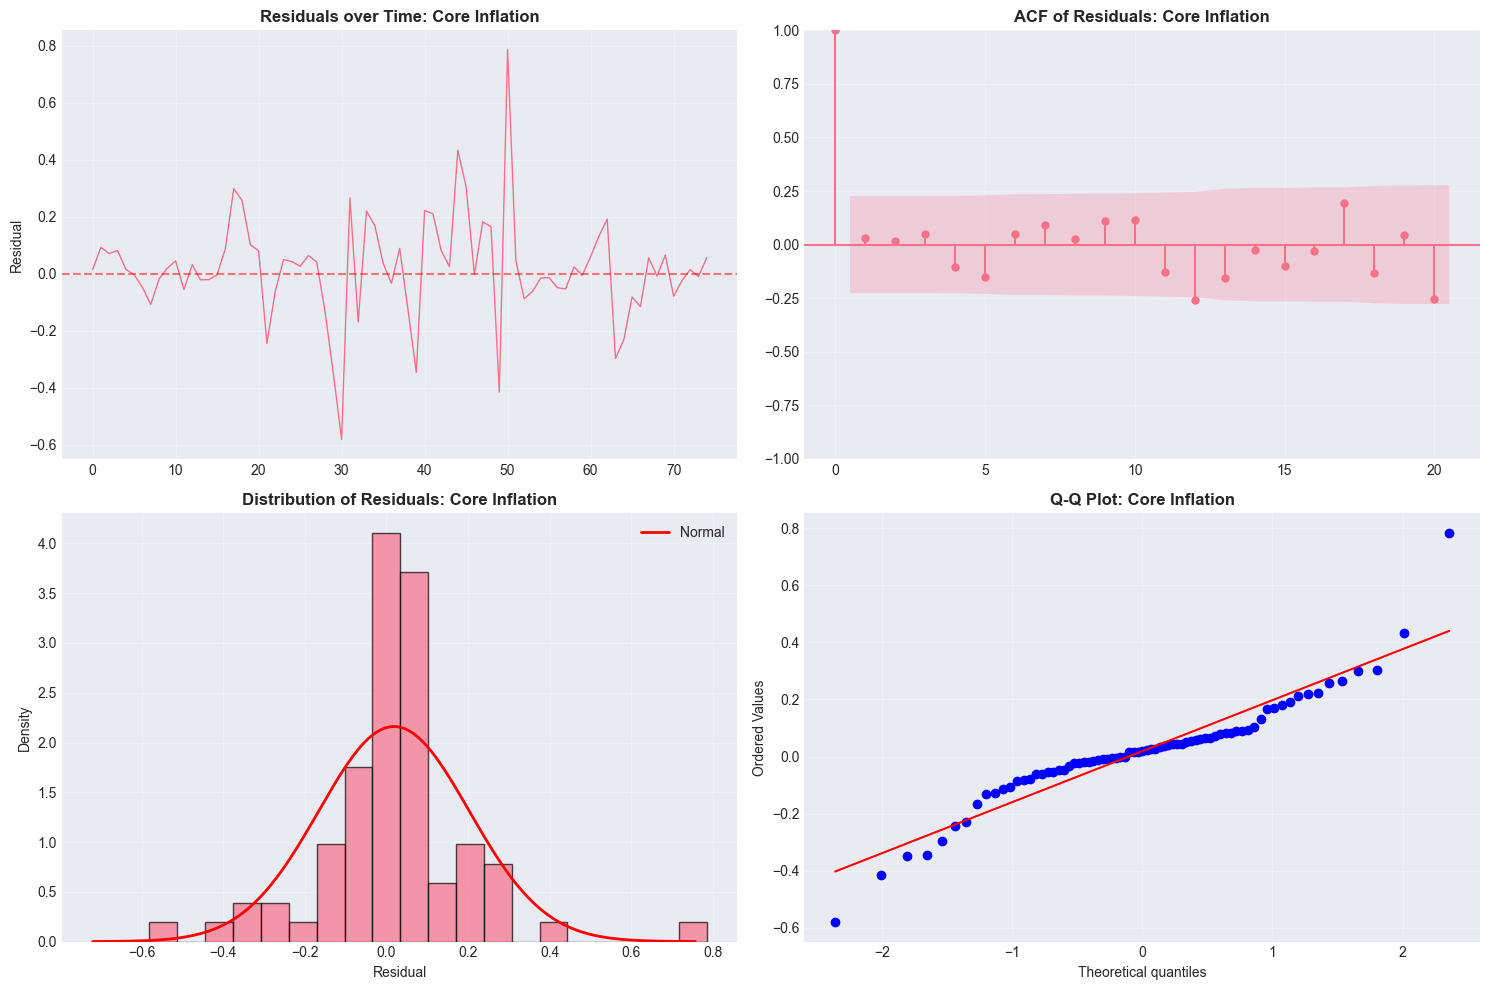

In [ ]:
core_idx_diag = vecm_vars_log.index(core_var_name)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

ax = axes[0, 0]
ax.plot(residuals[:, core_idx_diag], linewidth=1)
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax.set_title('Residuals over Time: Core Inflation', fontweight='bold')
ax.set_ylabel('Residual')
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
plot_acf(residuals[:, core_idx_diag], lags=min(20, len(residuals)//2), ax=ax)
ax.set_title('ACF of Residuals: Core Inflation', fontweight='bold')
ax.grid(True, alpha=0.3)

ax = axes[1, 0]
res_core = residuals[:, core_idx_diag]
ax.hist(res_core, bins=20, density=True, alpha=0.7, edgecolor='black')
mu, sigma = np.mean(res_core), np.std(res_core)
if sigma > 0:
    x = np.linspace(mu - 4*sigma, mu + 4*sigma, 200)
    ax.plot(x, stats.norm.pdf(x, mu, sigma), color='red', linewidth=2, label='Normal')
ax.set_title('Distribution of Residuals: Core Inflation', fontweight='bold')
ax.set_xlabel('Residual')
ax.set_ylabel('Density')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
stats.probplot(res_core, dist='norm', plot=ax)
ax.set_title('Q-Q Plot: Core Inflation', fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 15. Subset Variable Selection

In [ ]:
print('Available variables:')
print(vecm_vars_log)

subset_configs = [
    {'name': '2-var: Core + M2', 'vars': [core_var_name, 'm2'] if 'm2' in vecm_vars_log else [core_var_name]},
    {'name': '3-var: Core + M2 + PPI', 'vars': [v for v in [core_var_name, 'm2', 'ppi_qoq'] if v in vecm_vars_log]},
    {'name': '4-var: Core + M2 + PPI + Gasoline', 'vars': [v for v in [core_var_name, 'm2', 'ppi_qoq', 'gasoline_world_last_log'] if v in vecm_vars_log]},
    {'name': '5-var: + Silver', 'vars': [v for v in [core_var_name, 'm2', 'ppi_qoq', 'gasoline_world_last_log', 'silver_last_log'] if v in vecm_vars_log]},
    {'name': 'All variables', 'vars': vecm_vars_log}
]

subset_results = []

for config in subset_configs:
    subset_name = config['name']
    subset_vars = config['vars']

    if len(subset_vars) < 2:
        continue

    try:
        var_indices = [vecm_vars_log.index(v) for v in subset_vars]
        endog_subset_train = endog_train[:, var_indices]
        endog_subset_test = endog_test[:, var_indices]

        K_sub = len(subset_vars)
        core_idx_sub = subset_vars.index(core_var_name)

        lag_sel = select_order(endog_subset_train, maxlags=min(4, max(1, len(endog_subset_train)//10)), deterministic='ci')
        # Use BIC as default for small samples; change to lag_sel.aic if desired.
        k_diff_sub = int(lag_sel.bic)

        rank_sel = select_coint_rank(
            endog=endog_subset_train,
            det_order=0,
            k_ar_diff=k_diff_sub,
            method='trace',
            signif=0.05
        )
        rank_sub = max(1, min(int(rank_sel.rank), K_sub - 1))

        model_sub = VECM(endog_subset_train, k_ar_diff=k_diff_sub, coint_rank=rank_sub, deterministic='ci')
        res_sub = model_sub.fit()
        preds_sub = res_sub.predict(steps=test_size)

        actual_core_sub = endog_subset_test[:, core_idx_sub]
        pred_core_sub = preds_sub[:, core_idx_sub]

        rmse_sub, mae_sub, r2_sub = forecast_metrics(actual_core_sub, pred_core_sub)

        try:
            whiteness_result = res_sub.test_whiteness(nlags=min(5, len(res_sub.resid)//3))
            whiteness_pval = getattr(whiteness_result, 'pvalue', np.nan)
        except Exception:
            whiteness_pval = np.nan

        jb_fails = 0
        for i in range(K_sub):
            res_i = res_sub.resid[:, i]
            _, jb_pval = jarque_bera(res_i)
            if jb_pval < 0.05:
                jb_fails += 1

        subset_results.append({
            'Config': subset_name,
            'n_vars': K_sub,
            'k_ar_diff': k_diff_sub,
            'rank': rank_sub,
            'RMSE': rmse_sub,
            'MAE': mae_sub,
            'R2': r2_sub,
            'Whiteness_p': whiteness_pval,
            'JB_fails': jb_fails
        })

        print(f'\n{subset_name}')
        print(f'Variables: {subset_vars}')
        print(f'Lag: {k_diff_sub}, Rank: {rank_sub}')
        print(f'R2: {r2_sub:.4f}, RMSE: {rmse_sub:.6f}, Whiteness p: {whiteness_pval}')

    except Exception as e:
        print(f'\n{subset_name} failed: {e}')

subset_results_df = pd.DataFrame(subset_results)
if not subset_results_df.empty:
    subset_results_df['score'] = -subset_results_df['RMSE'] - 0.05 * subset_results_df['JB_fails']
    print('\nSubset model comparison:')
    print(subset_results_df.sort_values('RMSE').to_string(index=False))

Available variables:
['core_inflation_rate_log', 'm2', 'gasoline_world_last_log', 'silver_last_log', 'S&P500_last_log', 'USDVND_last_log', 'UPCOM_last_log', 'ppi_qoq']

2-var: Core + M2
Variables: ['core_inflation_rate_log', 'm2']
Lag: 0, Rank: 1
R2: -0.7204, RMSE: 0.121979, Whiteness p: 0.14865047837755424

3-var: Core + M2 + PPI
Variables: ['core_inflation_rate_log', 'm2', 'ppi_qoq']
Lag: 0, Rank: 1
R2: -1.6198, RMSE: 0.150522, Whiteness p: 0.0353636408147812

4-var: Core + M2 + PPI + Gasoline
Variables: ['core_inflation_rate_log', 'm2', 'ppi_qoq', 'gasoline_world_last_log']
Lag: 0, Rank: 1
R2: -15.9755, RMSE: 0.383159, Whiteness p: 0.04372178597175732

5-var: + Silver
Variables: ['core_inflation_rate_log', 'm2', 'ppi_qoq', 'gasoline_world_last_log', 'silver_last_log']
Lag: 0, Rank: 1
R2: -41.0707, RMSE: 0.603194, Whiteness p: 0.14087719486067435

All variables
Variables: ['core_inflation_rate_log', 'm2', 'gasoline_world_last_log', 'silver_last_log', 'S&P500_last_log', 'USDVND_last_l

## 16. Alternative Models: AR, ARIMAX and Random Walk

In [ ]:
from sklearn.linear_model import LinearRegression

core_train = endog_train[:, core_idx]
core_test = endog_test[:, core_idx]

alternatives = []

print('AR Models with recursive multi-step forecast:')
for p in [1, 2, 3, 4]:
    if len(core_train) <= p:
        continue
    try:
        X_train = np.column_stack([core_train[p-i-1:len(core_train)-i-1] for i in range(p)])
        y_train = core_train[p:]

        ar_model = LinearRegression()
        ar_model.fit(X_train, y_train)

        y_pred = []
        current = core_train[-p:].copy()
        for _ in range(len(core_test)):
            features = current[-p:][::-1].reshape(1, -1)
            pred = ar_model.predict(features)[0]
            y_pred.append(pred)
            current = np.append(current, pred)[1:]  # use prediction, not actual test value

        y_pred = np.array(y_pred)
        rmse, mae, r2 = forecast_metrics(core_test, y_pred)
        alternatives.append({'method': f'AR({p})', 'r2': r2, 'rmse': rmse, 'mae': mae})
        print(f'AR({p}): R2={r2:.4f}, RMSE={rmse:.6f}')
    except Exception as e:
        print(f'AR({p}) failed: {e}')

if 'm2' in vecm_vars_log:
    print('\nARIMAX-like linear model with M2 as exogenous variable:')
    m2_idx = vecm_vars_log.index('m2')
    m2_train = endog_train[:, m2_idx]
    m2_test = endog_test[:, m2_idx]

    for p in [1, 2, 3]:
        if len(core_train) <= p:
            continue
        try:
            ar_lags = np.column_stack([core_train[p-i-1:len(core_train)-i-1] for i in range(p)])
            X_train = np.column_stack([ar_lags, m2_train[p:]])
            y_train = core_train[p:]

            model = LinearRegression()
            model.fit(X_train, y_train)

            y_pred = []
            current_core = core_train[-p:].copy()
            for i in range(len(core_test)):
                ar_feat = current_core[-p:][::-1].reshape(1, -1)
                exog_feat = np.array([[m2_test[i]]])
                features = np.hstack([ar_feat, exog_feat])
                pred = model.predict(features)[0]
                y_pred.append(pred)
                current_core = np.append(current_core, pred)[1:]  # use prediction

            y_pred = np.array(y_pred)
            rmse, mae, r2 = forecast_metrics(core_test, y_pred)
            alternatives.append({'method': f'ARIMAX-like AR={p}', 'r2': r2, 'rmse': rmse, 'mae': mae})
            print(f'ARIMAX-like AR={p}: R2={r2:.4f}, RMSE={rmse:.6f}')
        except Exception as e:
            print(f'ARIMAX-like AR={p} failed: {e}')

rw_pred = np.repeat(core_train[-1], len(core_test))
rmse_rw, mae_rw, r2_rw = forecast_metrics(core_test, rw_pred)
alternatives.append({'method': 'Random Walk', 'r2': r2_rw, 'rmse': rmse_rw, 'mae': mae_rw})

mean_pred = np.repeat(np.mean(core_train), len(core_test))
rmse_mean, mae_mean, r2_mean = forecast_metrics(core_test, mean_pred)
alternatives.append({'method': 'Train Mean', 'r2': r2_mean, 'rmse': rmse_mean, 'mae': mae_mean})

alt_df = pd.DataFrame(alternatives).sort_values('rmse')
print('\nSummary of alternative models:')
print(alt_df.to_string(index=False))

AR Models with recursive multi-step forecast:
AR(1): R2=-9.5032, RMSE=0.301389
AR(2): R2=-10.2893, RMSE=0.312464
AR(3): R2=-13.0843, RMSE=0.349007
AR(4): R2=-16.6214, RMSE=0.390379

ARIMAX-like linear model with M2 as exogenous variable:
ARIMAX-like AR=1: R2=-8.0731, RMSE=0.280121
ARIMAX-like AR=2: R2=-9.1582, RMSE=0.296398
ARIMAX-like AR=3: R2=-13.2121, RMSE=0.350587

Summary of alternative models:
          method         r2     rmse      mae
     Random Walk  -6.342809 0.251999 0.234211
ARIMAX-like AR=1  -8.073117 0.280121 0.219550
ARIMAX-like AR=2  -9.158194 0.296398 0.223858
           AR(1)  -9.503166 0.301389 0.280062
           AR(2) -10.289265 0.312464 0.290396
           AR(3) -13.084253 0.349007 0.325170
ARIMAX-like AR=3 -13.212069 0.350587 0.233252
           AR(4) -16.621364 0.390379 0.364526
      Train Mean -26.471588 0.487426 0.478472


In [38]:
# ============================================================
# FULL CODE: IMPROVE VECM VARIABLE SELECTION
# ============================================================

import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.vector_ar.vecm import VECM, select_order, select_coint_rank
from scipy.stats import jarque_bera


# ============================================================
# 1. Prepare data
# ============================================================

base_vars = [
    'core_inflation_rate',
    'm2',
    'gasoline_world_last',
    'silver_last',
    'S&P500_last',
    'USDVND_last',
    'UPCOM_last',
    'ppi_qoq'
]

base_vars = [v for v in base_vars if v in cleaned_data.columns]

df_model = cleaned_data[['date'] + base_vars].copy()
df_model['date'] = pd.to_datetime(df_model['date'])
df_model = df_model.sort_values('date').dropna().reset_index(drop=True)

print("=" * 100)
print("DATA PREPARATION")
print("=" * 100)
print(f"Observations: {len(df_model)}")
print(f"Variables available: {base_vars}")
print(f"Date range: {df_model['date'].min().date()} to {df_model['date'].max().date()}")


# ============================================================
# 2. Transform variables
#    Force log-transform for M2 and other positive level variables
# ============================================================

df_trans = df_model.copy()

force_log_vars = [
    'core_inflation_rate',
    'm2',
    'gasoline_world_last',
    'silver_last',
    'S&P500_last',
    'USDVND_last',
    'UPCOM_last'
]

print("\n" + "=" * 100)
print("VARIABLE TRANSFORMATION")
print("=" * 100)

for col in force_log_vars:
    if col in df_trans.columns:
        if (df_trans[col] > 0).all():
            df_trans[f'{col}_log'] = np.log(df_trans[col])
            print(f"Log transformed: {col} -> {col}_log")
        else:
            print(f"Cannot log-transform {col}: contains non-positive values")

if 'ppi_qoq' in df_trans.columns:
    print("ppi_qoq kept in original scale")

print("\nColumns after transformation:")
print([c for c in df_trans.columns if c != 'date'])


# ============================================================
# 3. Stationarity check: ADF and KPSS
# ============================================================

def stationarity_check(series, name):
    series = pd.Series(series).dropna()

    result = {
        'Variable': name,
        'ADF_level_p': np.nan,
        'ADF_diff_p': np.nan,
        'KPSS_level_p': np.nan,
        'KPSS_diff_p': np.nan,
        'Suggested': None
    }

    try:
        result['ADF_level_p'] = adfuller(series, autolag='AIC')[1]
    except Exception:
        pass

    try:
        result['ADF_diff_p'] = adfuller(series.diff().dropna(), autolag='AIC')[1]
    except Exception:
        pass

    try:
        result['KPSS_level_p'] = kpss(series, regression='c', nlags='auto')[1]
    except Exception:
        pass

    try:
        result['KPSS_diff_p'] = kpss(series.diff().dropna(), regression='c', nlags='auto')[1]
    except Exception:
        pass

    adf_level = result['ADF_level_p']
    adf_diff = result['ADF_diff_p']

    if pd.notna(adf_level) and pd.notna(adf_diff):
        if adf_level > 0.05 and adf_diff < 0.05:
            result['Suggested'] = 'Likely I(1)'
        elif adf_level < 0.05:
            result['Suggested'] = 'Likely I(0)'
        else:
            result['Suggested'] = 'Unclear'
    else:
        result['Suggested'] = 'Test failed'

    return result


candidate_stationarity_vars = [
    'core_inflation_rate_log',
    'm2_log',
    'gasoline_world_last_log',
    'silver_last_log',
    'S&P500_last_log',
    'USDVND_last_log',
    'UPCOM_last_log',
    'ppi_qoq'
]

candidate_stationarity_vars = [
    v for v in candidate_stationarity_vars if v in df_trans.columns
]

stationarity_results = []

for var in candidate_stationarity_vars:
    stationarity_results.append(
        stationarity_check(df_trans[var], var)
    )

stationarity_df = pd.DataFrame(stationarity_results)

print("\n" + "=" * 100)
print("STATIONARITY CHECK")
print("=" * 100)
print(stationarity_df.to_string(index=False))


# ============================================================
# 4. Helper function: forecast metrics
# ============================================================

def forecast_metrics(actual, predicted):
    actual = np.asarray(actual)
    predicted = np.asarray(predicted)

    rmse = np.sqrt(np.mean((actual - predicted) ** 2))
    mae = np.mean(np.abs(actual - predicted))

    ss_res = np.sum((actual - predicted) ** 2)
    ss_tot = np.sum((actual - np.mean(actual)) ** 2)

    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

    return rmse, mae, r2


# ============================================================
# 5. Helper function: evaluate standard VECM
# ============================================================

def evaluate_vecm_model(
    df,
    endog_vars,
    target_var='core_inflation_rate_log',
    criterion='bic',
    maxlags=4,
    deterministic='ci',
    test_ratio=0.2
):
    """
    Fit and evaluate VECM using only endogenous variables.
    """

    try:
        df_sub = df[endog_vars].dropna().copy()
        data = df_sub.values

        n_obs = data.shape[0]
        train_size = int(n_obs * (1 - test_ratio))
        test_size = n_obs - train_size

        endog_train = data[:train_size]
        endog_test = data[train_size:]

        K = endog_train.shape[1]

        if target_var not in endog_vars:
            raise ValueError(f"{target_var} not in endog_vars")

        target_idx = endog_vars.index(target_var)

        if K < 2:
            raise ValueError("VECM requires at least 2 endogenous variables")

        maxlags_adj = min(maxlags, max(1, train_size // 10))

        lag_sel = select_order(
            endog_train,
            maxlags=maxlags_adj,
            deterministic=deterministic
        )

        if criterion.lower() == 'aic':
            k_diff = int(lag_sel.aic)
        elif criterion.lower() == 'hqic':
            k_diff = int(lag_sel.hqic)
        else:
            k_diff = int(lag_sel.bic)

        rank_sel = select_coint_rank(
            endog=endog_train,
            det_order=0,
            k_ar_diff=k_diff,
            method='trace',
            signif=0.05
        )

        rank = int(rank_sel.rank)
        rank = max(1, min(rank, K - 1))

        model = VECM(
            endog=endog_train,
            k_ar_diff=k_diff,
            coint_rank=rank,
            deterministic=deterministic
        )

        res = model.fit()

        preds = res.predict(steps=test_size)

        actual = endog_test[:, target_idx]
        pred = preds[:, target_idx]

        rmse, mae, r2 = forecast_metrics(actual, pred)

        rw_pred = np.repeat(endog_train[-1, target_idx], test_size)
        rmse_rw, mae_rw, r2_rw = forecast_metrics(actual, rw_pred)

        mean_pred = np.repeat(np.mean(endog_train[:, target_idx]), test_size)
        rmse_mean, mae_mean, r2_mean = forecast_metrics(actual, mean_pred)

        try:
            white_lag = min(5, max(2, len(res.resid) // 4))
            whiteness_result = res.test_whiteness(nlags=white_lag)
            whiteness_p = getattr(whiteness_result, 'pvalue', np.nan)
        except Exception:
            whiteness_p = np.nan

        jb_fails = 0
        for i in range(K):
            try:
                _, jb_p = jarque_bera(res.resid[:, i])
                if jb_p < 0.05:
                    jb_fails += 1
            except Exception:
                pass

        return {
            'status': 'success',
            'n_obs': n_obs,
            'train_size': train_size,
            'test_size': test_size,
            'n_vars': K,
            'vars': endog_vars,
            'k_ar_diff': k_diff,
            'VAR_level_lag_p': k_diff + 1,
            'rank': rank,
            'RMSE': rmse,
            'MAE': mae,
            'R2': r2,
            'RMSE_RW': rmse_rw,
            'MAE_RW': mae_rw,
            'R2_RW': r2_rw,
            'RMSE_Mean': rmse_mean,
            'MAE_Mean': mae_mean,
            'R2_Mean': r2_mean,
            'VECM_vs_RW': rmse / rmse_rw if rmse_rw > 0 else np.nan,
            'VECM_vs_Mean': rmse / rmse_mean if rmse_mean > 0 else np.nan,
            'Whiteness_p': whiteness_p,
            'JB_fails': jb_fails,
            'model_result': res,
            'preds': preds,
            'actual': actual,
            'pred': pred
        }

    except Exception as e:
        return {
            'status': 'failed',
            'vars': endog_vars,
            'error': str(e)
        }


# ============================================================
# 6. Standard VECM model configurations
# ============================================================

model_configs = [
    {
        'name': 'Core + log M2',
        'vars': [
            'core_inflation_rate_log',
            'm2_log'
        ]
    },
    {
        'name': 'Monetary: Core + log M2 + USDVND',
        'vars': [
            'core_inflation_rate_log',
            'm2_log',
            'USDVND_last_log'
        ]
    },
    {
        'name': 'Cost-push: Core + PPI + Gasoline',
        'vars': [
            'core_inflation_rate_log',
            'ppi_qoq',
            'gasoline_world_last_log'
        ]
    },
    {
        'name': 'Domestic macro: Core + M2 + USDVND + PPI',
        'vars': [
            'core_inflation_rate_log',
            'm2_log',
            'USDVND_last_log',
            'ppi_qoq'
        ]
    },
    {
        'name': 'Core + M2 + USDVND + PPI + Gasoline',
        'vars': [
            'core_inflation_rate_log',
            'm2_log',
            'USDVND_last_log',
            'ppi_qoq',
            'gasoline_world_last_log'
        ]
    },
    {
        'name': 'Financial extended',
        'vars': [
            'core_inflation_rate_log',
            'm2_log',
            'USDVND_last_log',
            'UPCOM_last_log',
            'S&P500_last_log'
        ]
    },
    {
        'name': 'All variables with log M2',
        'vars': [
            'core_inflation_rate_log',
            'm2_log',
            'gasoline_world_last_log',
            'silver_last_log',
            'S&P500_last_log',
            'USDVND_last_log',
            'UPCOM_last_log',
            'ppi_qoq'
        ]
    }
]


# ============================================================
# 7. Run standard VECM models
# ============================================================

standard_results = []
standard_fitted_models = {}

print("\n" + "=" * 100)
print("STANDARD VECM MODELS: ENDOGENOUS VARIABLES ONLY")
print("=" * 100)

for config in model_configs:
    name = config['name']
    vars_ = [v for v in config['vars'] if v in df_trans.columns]

    if len(vars_) < 2:
        print(f"\nSkip {name}: not enough variables")
        continue

    print(f"\nRunning: {name}")
    print(f"Variables: {vars_}")

    out = evaluate_vecm_model(
        df=df_trans,
        endog_vars=vars_,
        target_var='core_inflation_rate_log',
        criterion='bic',
        maxlags=4,
        deterministic='ci',
        test_ratio=0.2
    )

    if out['status'] == 'success':
        standard_fitted_models[name] = out

        standard_results.append({
            'Type': 'Endogenous only',
            'Model': name,
            'n_vars': out['n_vars'],
            'k_ar_diff': out['k_ar_diff'],
            'VAR_p': out['VAR_level_lag_p'],
            'rank': out['rank'],
            'RMSE': out['RMSE'],
            'MAE': out['MAE'],
            'R2': out['R2'],
            'RMSE_RW': out['RMSE_RW'],
            'VECM_vs_RW': out['VECM_vs_RW'],
            'RMSE_Mean': out['RMSE_Mean'],
            'VECM_vs_Mean': out['VECM_vs_Mean'],
            'Whiteness_p': out['Whiteness_p'],
            'JB_fails': out['JB_fails']
        })

        print(f"RMSE: {out['RMSE']:.6f}")
        print(f"MAE : {out['MAE']:.6f}")
        print(f"R2  : {out['R2']:.4f}")
        print(f"VECM/RW RMSE: {out['VECM_vs_RW']:.4f}")
        print(f"Whiteness p-value: {out['Whiteness_p']}")
        print(f"JB failures: {out['JB_fails']}/{out['n_vars']}")

    else:
        print(f"Failed: {out['error']}")

standard_results_df = pd.DataFrame(standard_results)

print("\n" + "=" * 100)
print("STANDARD VECM SUMMARY")
print("=" * 100)

if not standard_results_df.empty:
    standard_results_df = standard_results_df.sort_values('RMSE')
    print(standard_results_df.to_string(index=False))
else:
    print("No valid standard VECM models found.")


# ============================================================
# 8. Helper function: VECM with exogenous variables
# ============================================================

def evaluate_vecm_with_exog(
    df,
    endog_vars,
    exog_vars,
    target_var='core_inflation_rate_log',
    criterion='bic',
    maxlags=4,
    deterministic='ci',
    test_ratio=0.2
):
    """
    Fit and evaluate VECM with exogenous variables.
    """

    try:
        full_vars = endog_vars + exog_vars
        df_sub = df[full_vars].dropna().copy()

        y = df_sub[endog_vars].values
        X = df_sub[exog_vars].values if len(exog_vars) > 0 else None

        n_obs = y.shape[0]
        train_size = int(n_obs * (1 - test_ratio))
        test_size = n_obs - train_size

        y_train = y[:train_size]
        y_test = y[train_size:]

        if X is not None:
            X_train = X[:train_size]
            X_test = X[train_size:]
        else:
            X_train = None
            X_test = None

        K = y_train.shape[1]

        if target_var not in endog_vars:
            raise ValueError(f"{target_var} not in endog_vars")

        target_idx = endog_vars.index(target_var)

        if K < 2:
            raise ValueError("VECM requires at least 2 endogenous variables")

        maxlags_adj = min(maxlags, max(1, train_size // 10))

        lag_sel = select_order(
            y_train,
            maxlags=maxlags_adj,
            deterministic=deterministic,
            exog=X_train
        )

        if criterion.lower() == 'aic':
            k_diff = int(lag_sel.aic)
        elif criterion.lower() == 'hqic':
            k_diff = int(lag_sel.hqic)
        else:
            k_diff = int(lag_sel.bic)

        rank_sel = select_coint_rank(
            endog=y_train,
            det_order=0,
            k_ar_diff=k_diff,
            method='trace',
            signif=0.05
        )

        rank = int(rank_sel.rank)
        rank = max(1, min(rank, K - 1))

        model = VECM(
            endog=y_train,
            exog=X_train,
            k_ar_diff=k_diff,
            coint_rank=rank,
            deterministic=deterministic
        )

        res = model.fit()

        if X_test is not None:
            preds = res.predict(steps=test_size, exog_fc=X_test)
        else:
            preds = res.predict(steps=test_size)

        actual = y_test[:, target_idx]
        pred = preds[:, target_idx]

        rmse, mae, r2 = forecast_metrics(actual, pred)

        rw_pred = np.repeat(y_train[-1, target_idx], test_size)
        rmse_rw, mae_rw, r2_rw = forecast_metrics(actual, rw_pred)

        mean_pred = np.repeat(np.mean(y_train[:, target_idx]), test_size)
        rmse_mean, mae_mean, r2_mean = forecast_metrics(actual, mean_pred)

        try:
            white_lag = min(5, max(2, len(res.resid) // 4))
            whiteness_result = res.test_whiteness(nlags=white_lag)
            whiteness_p = getattr(whiteness_result, 'pvalue', np.nan)
        except Exception:
            whiteness_p = np.nan

        jb_fails = 0
        for i in range(K):
            try:
                _, jb_p = jarque_bera(res.resid[:, i])
                if jb_p < 0.05:
                    jb_fails += 1
            except Exception:
                pass

        return {
            'status': 'success',
            'endog_vars': endog_vars,
            'exog_vars': exog_vars,
            'n_endog': len(endog_vars),
            'n_exog': len(exog_vars),
            'k_ar_diff': k_diff,
            'VAR_p': k_diff + 1,
            'rank': rank,
            'RMSE': rmse,
            'MAE': mae,
            'R2': r2,
            'RMSE_RW': rmse_rw,
            'VECM_vs_RW': rmse / rmse_rw if rmse_rw > 0 else np.nan,
            'RMSE_Mean': rmse_mean,
            'VECM_vs_Mean': rmse / rmse_mean if rmse_mean > 0 else np.nan,
            'Whiteness_p': whiteness_p,
            'JB_fails': jb_fails,
            'model_result': res,
            'preds': preds,
            'actual': actual,
            'pred': pred
        }

    except Exception as e:
        return {
            'status': 'failed',
            'error': str(e),
            'endog_vars': endog_vars,
            'exog_vars': exog_vars
        }


# ============================================================
# 9. Exogenous variable model configurations
# ============================================================

exog_configs = [
    {
        'name': 'Endog Core+M2+USDVND, Exog Gasoline',
        'endog': [
            'core_inflation_rate_log',
            'm2_log',
            'USDVND_last_log'
        ],
        'exog': [
            'gasoline_world_last_log'
        ]
    },
    {
        'name': 'Endog Core+M2, Exog Gasoline+USDVND',
        'endog': [
            'core_inflation_rate_log',
            'm2_log'
        ],
        'exog': [
            'gasoline_world_last_log',
            'USDVND_last_log'
        ]
    },
    {
        'name': 'Endog Core+M2+PPI, Exog Gasoline+SP500+Silver',
        'endog': [
            'core_inflation_rate_log',
            'm2_log',
            'ppi_qoq'
        ],
        'exog': [
            'gasoline_world_last_log',
            'S&P500_last_log',
            'silver_last_log'
        ]
    },
    {
        'name': 'Endog Core+M2+USDVND+PPI, Exog international',
        'endog': [
            'core_inflation_rate_log',
            'm2_log',
            'USDVND_last_log',
            'ppi_qoq'
        ],
        'exog': [
            'gasoline_world_last_log',
            'S&P500_last_log',
            'silver_last_log'
        ]
    },
    {
        'name': 'Endog Core+M2, Exog international+UPCOM',
        'endog': [
            'core_inflation_rate_log',
            'm2_log'
        ],
        'exog': [
            'gasoline_world_last_log',
            'S&P500_last_log',
            'silver_last_log',
            'UPCOM_last_log',
            'USDVND_last_log'
        ]
    }
]


# ============================================================
# 10. Run VECM models with exogenous variables
# ============================================================

exog_results = []
exog_fitted_models = {}

print("\n" + "=" * 100)
print("VECM MODELS WITH EXOGENOUS VARIABLES")
print("=" * 100)

for config in exog_configs:
    name = config['name']
    endog_vars = [v for v in config['endog'] if v in df_trans.columns]
    exog_vars = [v for v in config['exog'] if v in df_trans.columns]

    print(f"\nRunning: {name}")
    print(f"Endogenous: {endog_vars}")
    print(f"Exogenous : {exog_vars}")

    if len(endog_vars) < 2:
        print("Skipped: not enough endogenous variables")
        continue

    out = evaluate_vecm_with_exog(
        df=df_trans,
        endog_vars=endog_vars,
        exog_vars=exog_vars,
        target_var='core_inflation_rate_log',
        criterion='bic',
        maxlags=4,
        deterministic='ci',
        test_ratio=0.2
    )

    if out['status'] == 'success':
        exog_fitted_models[name] = out

        exog_results.append({
            'Type': 'With exogenous',
            'Model': name,
            'n_vars': out['n_endog'],
            'n_exog': out['n_exog'],
            'k_ar_diff': out['k_ar_diff'],
            'VAR_p': out['VAR_p'],
            'rank': out['rank'],
            'RMSE': out['RMSE'],
            'MAE': out['MAE'],
            'R2': out['R2'],
            'RMSE_RW': out['RMSE_RW'],
            'VECM_vs_RW': out['VECM_vs_RW'],
            'RMSE_Mean': out['RMSE_Mean'],
            'VECM_vs_Mean': out['VECM_vs_Mean'],
            'Whiteness_p': out['Whiteness_p'],
            'JB_fails': out['JB_fails']
        })

        print(f"RMSE: {out['RMSE']:.6f}")
        print(f"MAE : {out['MAE']:.6f}")
        print(f"R2  : {out['R2']:.4f}")
        print(f"VECM/RW RMSE: {out['VECM_vs_RW']:.4f}")
        print(f"Whiteness p-value: {out['Whiteness_p']}")
        print(f"JB failures: {out['JB_fails']}/{out['n_endog']}")

    else:
        print(f"Failed: {out['error']}")

exog_results_df = pd.DataFrame(exog_results)

print("\n" + "=" * 100)
print("VECM WITH EXOGENOUS VARIABLES SUMMARY")
print("=" * 100)

if not exog_results_df.empty:
    exog_results_df = exog_results_df.sort_values('RMSE')
    print(exog_results_df.to_string(index=False))
else:
    print("No valid exogenous VECM models found.")


# ============================================================
# 11. Combine all results
# ============================================================

all_results = []

if not standard_results_df.empty:
    temp_std = standard_results_df.copy()
    if 'n_exog' not in temp_std.columns:
        temp_std['n_exog'] = 0
    all_results.append(temp_std)

if not exog_results_df.empty:
    temp_exog = exog_results_df.copy()
    all_results.append(temp_exog)

print("\n" + "=" * 100)
print("FINAL MODEL COMPARISON")
print("=" * 100)

if all_results:
    final_compare_df = pd.concat(all_results, ignore_index=True, sort=False)

    # Practical score:
    # lower RMSE is better
    # penalize many JB failures
    # penalize failure to beat Random Walk
    final_compare_df['beats_RW'] = final_compare_df['VECM_vs_RW'] < 1
    final_compare_df['Whiteness_pass'] = final_compare_df['Whiteness_p'] > 0.05

    final_compare_df['score'] = (
        -final_compare_df['RMSE']
        - 0.05 * final_compare_df['JB_fails'].fillna(0)
        + 0.10 * final_compare_df['beats_RW'].astype(int)
        + 0.05 * final_compare_df['Whiteness_pass'].astype(int)
    )

    final_compare_df = final_compare_df.sort_values('RMSE')

    display_cols = [
        'Type',
        'Model',
        'n_vars',
        'n_exog',
        'k_ar_diff',
        'VAR_p',
        'rank',
        'RMSE',
        'MAE',
        'R2',
        'RMSE_RW',
        'VECM_vs_RW',
        'RMSE_Mean',
        'VECM_vs_Mean',
        'Whiteness_p',
        'JB_fails',
        'beats_RW',
        'Whiteness_pass',
        'score'
    ]

    display_cols = [c for c in display_cols if c in final_compare_df.columns]

    print(final_compare_df[display_cols].to_string(index=False))

    best_by_rmse = final_compare_df.iloc[0]
    best_by_score = final_compare_df.sort_values('score', ascending=False).iloc[0]

    print("\n" + "=" * 100)
    print("BEST MODEL BY RMSE")
    print("=" * 100)
    print(best_by_rmse[display_cols])

    print("\n" + "=" * 100)
    print("BEST MODEL BY PRACTICAL SCORE")
    print("=" * 100)
    print(best_by_score[display_cols])

else:
    print("No valid models to compare.")


# ============================================================
# 12. Extract best model object
# ============================================================

best_model_name = best_by_rmse['Model'] if all_results else None
best_model_type = best_by_rmse['Type'] if all_results else None

best_model_object = None
best_model_info = None

if best_model_name is not None:
    if best_model_type == 'Endogenous only':
        best_model_info = standard_fitted_models.get(best_model_name)
    elif best_model_type == 'With exogenous':
        best_model_info = exog_fitted_models.get(best_model_name)

    if best_model_info is not None:
        best_model_object = best_model_info['model_result']

        print("\n" + "=" * 100)
        print("BEST MODEL OBJECT READY")
        print("=" * 100)
        print(f"Best model name: {best_model_name}")
        print(f"Best model type: {best_model_type}")
        print("Use this object for further diagnostics or summary:")
        print("best_model_object")
    else:
        print("Could not retrieve best model object.")


# ============================================================
# 13. Optional: print summary of best model
# ============================================================

try:
    print("\n" + "=" * 100)
    print("BEST MODEL SUMMARY")
    print("=" * 100)
    print(best_model_object.summary())
except Exception as e:
    print(f"Could not print best model summary: {e}")


# ============================================================
# 14. Interpretation guide
# ============================================================

print("\n" + "=" * 100)
print("INTERPRETATION GUIDE")
print("=" * 100)

print("""
How to read the result:

1. RMSE:
   Lower is better.

2. VECM_vs_RW:
   If VECM_vs_RW < 1, the VECM beats Random Walk.
   If VECM_vs_RW > 1, Random Walk is better.

3. R2:
   Out-of-sample R2 can be negative.
   Negative R2 means the model performs worse than using the test mean.

4. Whiteness_p:
   If Whiteness_p > 0.05, residual autocorrelation is not detected.
   This is good.

5. JB_fails:
   Number of residual equations that fail Jarque-Bera normality test.
   Lower is better.

6. Model choice:
   If the best RMSE model is Core + log M2, that supports using a smaller VECM.
   If models with exogenous variables perform better, international variables may be better treated as external shocks.
""")

DATA PREPARATION
Observations: 88
Variables available: ['core_inflation_rate', 'm2', 'gasoline_world_last', 'silver_last', 'S&P500_last', 'USDVND_last', 'UPCOM_last', 'ppi_qoq']
Date range: 2018-06-01 to 2025-09-01

VARIABLE TRANSFORMATION
Log transformed: core_inflation_rate -> core_inflation_rate_log
Log transformed: m2 -> m2_log
Log transformed: gasoline_world_last -> gasoline_world_last_log
Log transformed: silver_last -> silver_last_log
Log transformed: S&P500_last -> S&P500_last_log
Log transformed: USDVND_last -> USDVND_last_log
Log transformed: UPCOM_last -> UPCOM_last_log
ppi_qoq kept in original scale

Columns after transformation:
['core_inflation_rate', 'm2', 'gasoline_world_last', 'silver_last', 'S&P500_last', 'USDVND_last', 'UPCOM_last', 'ppi_qoq', 'core_inflation_rate_log', 'm2_log', 'gasoline_world_last_log', 'silver_last_log', 'S&P500_last_log', 'USDVND_last_log', 'UPCOM_last_log']

STATIONARITY CHECK
               Variable  ADF_level_p   ADF_diff_p  KPSS_level_p  KPS